# SASBDB access notebook

Programmatic access to the Small Angle Scattering Biological Data Bank.

**Two different things live at two different places:**

| What | Where | How |
|---|---|---|
| Metadata (codes, summaries, Rg, Dmax, instrument, UniProt) | REST API, JSON | documented endpoints below |
| Actual data files (`.dat`, `.fit`, `.fir`, `.out`, models, zip) | the website's media paths | **not** in the REST API docs — discovered at runtime |

The REST API is a metadata service. It does not document file download URLs. Section 4
discovers them from the summary JSON and, failing that, from the entry page HTML, rather
than hardcoding a URL pattern that may change.

**Untested against the live server.** Run Section 2 first — it prints the real response
shape so you can correct any field-name guesses in Section 4 before they matter.

**Be polite.** SASBDB is a small academic service. The client below rate-limits and caches
to disk; do not remove either when looping over many entries.

## 1. Setup

In [1]:
# !pip install requests pandas numpy matplotlib
import json, re, time, hashlib
from pathlib import Path
from dataclasses import dataclass, field

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "https://www.sasbdb.org"
API = f"{BASE}/rest-api"
SWAGGER = f"{API}/swagger/swagger.json"

CACHE_DIR = Path("sasbdb_cache")
DATA_DIR = Path("sasbdb_data")
CACHE_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# Identify yourself. Academic services appreciate it and it makes you easier to unblock.
CONTACT = "your.email@institution.edu"   # <-- EDIT
USER_AGENT = f"sasbdb-client/0.1 (+{CONTACT})"

REQUEST_DELAY_S = 0.5   # minimum gap between requests

In [2]:
class SASBDBClient:
    """Thin, cached, rate-limited wrapper over the SASBDB REST API and media files."""

    def __init__(self, cache_dir=CACHE_DIR, delay=REQUEST_DELAY_S, timeout=30):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.delay = delay
        self.timeout = timeout
        self._last_call = 0.0
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": USER_AGENT, "Accept": "application/json"})

    # -- internals -------------------------------------------------------
    def _throttle(self):
        gap = time.time() - self._last_call
        if gap < self.delay:
            time.sleep(self.delay - gap)
        self._last_call = time.time()

    def _cache_path(self, key, suffix):
        h = hashlib.sha1(key.encode()).hexdigest()[:16]
        return self.cache_dir / f"{h}{suffix}"

    # -- public ----------------------------------------------------------
    def get_json(self, url, params=None, use_cache=True):
        key = url + json.dumps(params or {}, sort_keys=True)
        cp = self._cache_path(key, ".json")
        if use_cache and cp.exists():
            return json.loads(cp.read_text())
        self._throttle()
        r = self.session.get(url, params=params, timeout=self.timeout)
        r.raise_for_status()
        data = r.json()
        cp.write_text(json.dumps(data))
        return data

    def post_json(self, url, payload, use_cache=True):
        key = url + json.dumps(payload, sort_keys=True)
        cp = self._cache_path(key, ".json")
        if use_cache and cp.exists():
            return json.loads(cp.read_text())
        self._throttle()
        r = self.session.post(url, data=payload, timeout=self.timeout)
        r.raise_for_status()
        data = r.json()
        cp.write_text(json.dumps(data))
        return data

    def get_text(self, url, use_cache=True):
        cp = self._cache_path(url, ".txt")
        if use_cache and cp.exists():
            return cp.read_text()
        self._throttle()
        r = self.session.get(url, timeout=self.timeout,
                             headers={"Accept": "text/html,*/*"})
        r.raise_for_status()
        cp.write_text(r.text)
        return r.text

    def download(self, url, dest: Path, overwrite=False):
        dest = Path(dest)
        dest.parent.mkdir(parents=True, exist_ok=True)
        if dest.exists() and not overwrite:
            return dest
        self._throttle()
        r = self.session.get(url, timeout=self.timeout, stream=True,
                             headers={"Accept": "*/*"})
        r.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in r.iter_content(8192):
                fh.write(chunk)
        return dest


sasbdb = SASBDBClient()
print("client ready; cache ->", CACHE_DIR.resolve())

client ready; cache -> C:\Users\anand\OneDrive - Syracuse University\SWAXS\SWAXS_github\Small-Wide-Angle-X-ray-Scattering---Biological-Molecules-1\notebooks\sasbdb_cache


## 2. Discovery — run this before trusting anything below

Two cells. The first pulls the OpenAPI spec, which is the authoritative list of paths and
query parameters (it resolves what `/entry/summary/` actually accepts as a query string,
which the HTML docs leave vague). The second dumps one entry's summary so you can see the
real field names.

In [3]:
try:
    spec = sasbdb.get_json(SWAGGER)
    print("OpenAPI/Swagger version:", spec.get("swagger") or spec.get("openapi"))
    print("\nPaths:")
    for path, methods in sorted(spec.get("paths", {}).items()):
        for verb, meta in methods.items():
            params = [p.get("name") for p in meta.get("parameters", [])]
            print(f"  {verb.upper():4s} {path}")
            if params:
                print(f"        params: {params}")
except Exception as e:
    print("Could not fetch swagger:", repr(e))
    print("Fall back to the endpoint list in section 3.")

OpenAPI/Swagger version: 2.0

Paths:
  GET  /rest-api/entry/codes/all/
  GET  /rest-api/entry/codes/from_date/
        params: ['date']
  GET  /rest-api/entry/codes/molecular_type/dna/
  GET  /rest-api/entry/codes/molecular_type/heterocomplex/
  GET  /rest-api/entry/codes/molecular_type/other/
  GET  /rest-api/entry/codes/molecular_type/protein/
  GET  /rest-api/entry/codes/molecular_type/rna/
  GET  /rest-api/entry/codes/tags/{tag}/
        params: ['tag']
  GET  /rest-api/entry/codes/uniprot/{uniprot_code}/
        params: ['uniprot_code']
  GET  /rest-api/entry/summary/
        params: ['code']
  POST /rest-api/entry/summary/list/
        params: ['data']
  GET  /rest-api/entry/summary/{code}/
        params: ['code']
  GET  /rest-api/instrument/all/


In [4]:
PROBE_CODE = "SASDDF6"   # any released entry; change if this one moves

summary = sasbdb.get_json(f"{API}/entry/summary/{PROBE_CODE}/")

print("Top-level keys:")
for k, v in summary.items():
    preview = str(v)
    if len(preview) > 90:
        preview = preview[:90] + " ..."
    print(f"  {k:32s} {type(v).__name__:10s} {preview}")

print("\n--- full JSON ---")
print(json.dumps(summary, indent=2)[:4000])

Top-level keys:
  code                             str        SASDDF6
  status                           str        Published
  type_of_curve                    str        Single concentration
  angular_unit                     str        1/nm
  project                          dict       {'title': 'Internal nanosecond dynamics in the intrinsically disordered myelin basic prote ...
  pddf_data                        str        https://www.sasbdb.org/media/p_of_R_files/SASDDF6.out
  intensities_data                 str        https://www.sasbdb.org/media/intensities_files/SASDDF6.dat
  intensities_log_plot             str        https://www.sasbdb.org/media/intensities_files/scattering_plots/SASDDF6_dat_img.png
  intensities_kratky_plot          str        https://www.sasbdb.org/media/intensities_files/scattering_plots/SASDDF6_kratky_img.png
  pddf_plot                        str        https://www.sasbdb.org/media/p_of_R_files/pofr_images/SASDDF6_pofr_img.png
  intensities_guinier_plot

## 3. Metadata endpoints

Straight from the API documentation. Each returns JSON (XML also available server-side).

In [5]:
# ---- codes -----------------------------------------------------------
def list_all_codes():
    """Every SASBDB entry code. Large — cached after first call."""
    return sasbdb.get_json(f"{API}/entry/codes/all/")

def codes_from_date(date_str):
    """Entry codes filtered by release date. date_str format: check swagger output."""
    return sasbdb.get_json(f"{API}/entry/codes/from_date/", params={"date": date_str})

# ---- summaries -------------------------------------------------------
def summary(code):
    return sasbdb.get_json(f"{API}/entry/summary/{code}/")

def summary_query(**params):
    """Query-string search. Use the swagger output to see valid parameter names."""
    return sasbdb.get_json(f"{API}/entry/summary/", params=params)

def summary_list(codes):
    """POST a list of codes, get summaries back in one round trip. Chunk it."""
    out = []
    codes = list(codes)
    for i in range(0, len(codes), 50):
        chunk = codes[i:i + 50]
        out.extend(sasbdb.post_json(f"{API}/entry/summary/list/",
                                    {"codes": ",".join(chunk)}))
    return out

# ---- filtered code lists --------------------------------------------
def codes_by_tag(tag):
    return sasbdb.get_json(f"{API}/entry/codes/tags/{tag}/")

def codes_by_molecular_type(mtype):
    """mtype in {protein, rna, dna, heterocomplex, other}"""
    valid = {"protein", "rna", "dna", "heterocomplex", "other"}
    if mtype not in valid:
        raise ValueError(f"mtype must be one of {valid}")
    return sasbdb.get_json(f"{API}/entry/codes/molecular_type/{mtype}/")

def codes_by_uniprot(uniprot_code):
    return sasbdb.get_json(f"{API}/entry/codes/uniprot/{uniprot_code}/")

# ---- instruments -----------------------------------------------------
def all_instruments():
    return sasbdb.get_json(f"{API}/instrument/all/")

print("endpoint wrappers defined")

endpoint wrappers defined


In [6]:
# Smoke test
codes = list_all_codes()
print("total entries:", len(codes))
print("sample:", codes[:5] if isinstance(codes, list) else list(codes)[:5])

proteins = codes_by_molecular_type("protein")
print("protein-only entries:", len(proteins))

instruments = all_instruments()
print("instruments:", len(instruments))

total entries: 5613
sample: [{'code': 'SASDCZ9', 'status': 'Published'}, {'code': 'SASDFZ9', 'status': 'Published'}, {'code': 'SASDGZ9', 'status': 'Published'}, {'code': 'SASDHZ9', 'status': 'Published'}, {'code': 'SASDLZ9', 'status': 'Published'}]
protein-only entries: 4624
instruments: 164


In [7]:
def summaries_to_frame(codes, max_n=None):
    """Summaries -> DataFrame. Useful for filtering a benchmark set by Rg, MW, type."""
    codes = list(codes)[:max_n] if max_n else list(codes)
    rows = summary_list(codes)
    df = pd.json_normalize(rows)
    return df

# df = summaries_to_frame(proteins, max_n=100)
# df.head()

## 4. Data files

The REST API returns metadata, not files. This section finds the files two ways:

1. **Scan the summary JSON** for anything that looks like a path or URL. Cheap, and if
   SASBDB exposes file references in the summary this is the correct route.
2. **Parse the entry page HTML** for links with data extensions. The fallback.

Run `inspect_file_links()` on one entry first and read the output before looping.

In [8]:
DATA_EXTS = (".dat", ".fit", ".fir", ".out", ".pdb", ".cif", ".zip", ".txt", ".gnom")

def _walk_strings(obj, path=""):
    """Yield (json_path, string) for every string in a nested structure."""
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield from _walk_strings(v, f"{path}.{k}" if path else k)
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            yield from _walk_strings(v, f"{path}[{i}]")
    elif isinstance(obj, str):
        yield path, obj


def urls_from_summary(code):
    """Anything in the summary JSON that smells like a downloadable file."""
    s = summary(code)
    hits = []
    for jpath, val in _walk_strings(s):
        low = val.lower()
        if low.endswith(DATA_EXTS) or "/media/" in low or low.startswith("http"):
            url = val if val.startswith("http") else BASE + ("" if val.startswith("/") else "/") + val
            hits.append((jpath, url))
    return hits


def urls_from_entry_page(code):
    """Fallback: scrape hrefs off the public entry page."""
    html = sasbdb.get_text(f"{BASE}/data/{code}/")
    hrefs = re.findall(r'href=["\x27]([^"\x27]+)["\x27]', html)
    hits = []
    for h in hrefs:
        if h.lower().endswith(DATA_EXTS):
            url = h if h.startswith("http") else BASE + ("" if h.startswith("/") else "/") + h
            hits.append(url)
    return sorted(set(hits))


def inspect_file_links(code):
    print(f"=== {code} ===")
    print("\n[from summary JSON]")
    for jpath, url in urls_from_summary(code):
        print(f"  {jpath:40s} {url}")
    print("\n[from entry page HTML]")
    for url in urls_from_entry_page(code):
        print("  ", url)


inspect_file_links(PROBE_CODE)

=== SASDDF6 ===

[from summary JSON]
  pddf_data                                https://www.sasbdb.org/media/p_of_R_files/SASDDF6.out
  intensities_data                         https://www.sasbdb.org/media/intensities_files/SASDDF6.dat
  intensities_log_plot                     https://www.sasbdb.org/media/intensities_files/scattering_plots/SASDDF6_dat_img.png
  intensities_kratky_plot                  https://www.sasbdb.org/media/intensities_files/scattering_plots/SASDDF6_kratky_img.png
  pddf_plot                                https://www.sasbdb.org/media/p_of_R_files/pofr_images/SASDDF6_pofr_img.png
  intensities_guinier_plot                 https://www.sasbdb.org/media/intensities_files/scattering_plots/SASDDF6_guinier_img.png
  sascif_data                              https://www.sasbdb.org/media/sascif/sascif_files/SASDDF6.sascif
  experiment.contributor[0].affiliation[0].webpage https://www.fz-juelich.de
  fits[0].models[0].model_plot             https://www.sasbdb.org/media/pd

In [9]:
def fetch_entry_files(code, dest_root=DATA_DIR, exts=(".dat",), overwrite=False):
    """Download matching files for one entry into dest_root/<code>/."""
    urls = [u for _, u in urls_from_summary(code)]
    urls += urls_from_entry_page(code)
    urls = sorted(set(u for u in urls if u.lower().endswith(tuple(exts))))

    out = []
    for u in urls:
        name = u.rstrip("/").split("/")[-1]
        dest = Path(dest_root) / code / name
        try:
            out.append(sasbdb.download(u, dest, overwrite=overwrite))
        except Exception as e:
            print(f"  failed {u}: {e!r}")
    return out


files = fetch_entry_files(PROBE_CODE, exts=(".dat",))
for f in files:
    print(f, f.stat().st_size, "bytes")

sasbdb_data\SASDDF6\SASDDF6.dat 47652 bytes


## 5. Parsing scattering curves

SASBDB data are three columns: momentum transfer *s*, intensity *I(s)*, and the standard
deviation σ(I(s)). Two things vary between entries and both will bite you:

- **Units of s** — nm⁻¹ or Å⁻¹, depositor's choice.
- **Intensity scale** — arbitrary units or absolute (cm⁻¹).

The header often records this, sometimes not. `read_dat` keeps the header text so you can
check, and `detect_q_units` gives a heuristic with an explicit confidence flag. Never let
the heuristic run silently in a pipeline — log what it decided.

In [10]:
@dataclass
class SASCurve:
    q: np.ndarray            # momentum transfer, as read
    I: np.ndarray
    sigma: np.ndarray
    units: str = "unknown"   # "nm^-1" | "A^-1" | "unknown"
    header: str = ""
    source: str = ""

    def to_frame(self):
        return pd.DataFrame({"q": self.q, "I": self.I, "sigma": self.sigma})

    def __len__(self):
        return len(self.q)


def read_dat(path):
    path = Path(path)
    header_lines, rows = [], []
    for line in path.read_text(errors="replace").splitlines():
        s = line.strip()
        if not s:
            continue
        parts = s.replace(",", " ").split()
        try:
            vals = [float(p) for p in parts[:3]]
        except ValueError:
            header_lines.append(s)
            continue
        if len(vals) >= 2:
            rows.append((vals[0], vals[1], vals[2] if len(vals) > 2 else np.nan))

    if not rows:
        raise ValueError(f"no numeric rows parsed from {path}")

    arr = np.array(rows, dtype=float)
    return SASCurve(q=arr[:, 0], I=arr[:, 1], sigma=arr[:, 2],
                    header="\n".join(header_lines), source=str(path))


def detect_q_units(curve, verbose=True):
    """Heuristic. Typical bio-SAXS reaches q_max ~ 0.5 A^-1 == 5 nm^-1."""
    qmax = float(np.nanmax(curve.q))

    # 1. trust the header if it says so
    h = curve.header.lower()
    if "nm-1" in h or "nm^-1" in h or "1/nm" in h:
        units, confidence = "nm^-1", "header"
    elif "a-1" in h or "angstrom" in h or "1/a" in h or "\u00c5" in curve.header:
        units, confidence = "A^-1", "header"
    # 2. otherwise fall back on magnitude
    elif qmax < 2.0:
        units, confidence = "A^-1", "heuristic"
    else:
        units, confidence = "nm^-1", "heuristic"

    if verbose:
        print(f"q_max = {qmax:.4g}  ->  {units}  ({confidence})")
        if confidence == "heuristic" and 0.5 < qmax < 5.0:
            print("  WARNING: ambiguous range. Verify against the entry page before using.")
    curve.units = units
    return units


def to_inverse_nm(curve):
    """Return a copy with q in nm^-1 (the GROMACS-SWAXS convention)."""
    if curve.units == "unknown":
        detect_q_units(curve)
    factor = 10.0 if curve.units == "A^-1" else 1.0
    return SASCurve(q=curve.q * factor, I=curve.I.copy(), sigma=curve.sigma.copy(),
                    units="nm^-1", header=curve.header, source=curve.source)

In [11]:
if files:
    curve = read_dat(files[0])
    print("points:", len(curve))
    print("header:")
    print(curve.header[:600] or "  (none)")
    detect_q_units(curve)
    curve_nm = to_inverse_nm(curve)
    display(curve_nm.to_frame().head())

points: 1012
header:
# [5] MBP21
# Sample c= 5.0 mg/ml
#
# Number of frames collected: 10
# Exposure time per frame: 2.0
# WARNING: Radiation damage detected, merged 4 curves
# Merged from: /data/visitor/mx1493/bm29/1d/ARR_276_00001.dat
# Merged from: /data/visitor/mx1493/bm29/1d/ARR_276_00002.dat
# Merged from: /data/visitor/mx1493/bm29/1d/ARR_276_00003.dat
# Merged from: /data/visitor/mx1493/bm29/1d/ARR_276_00004.dat
#
# Sample Information:
# buffer
# Sample c= 0.0 mg/ml
#
# Number of frames collected: 10
# Exposure time per frame:
q_max = 4.525  ->  nm^-1  (heuristic)


,q,I,sigma
0,0.136728,18.9490,0.092286
1,0.141068,18.7639,0.089714
2,0.145409,18.7416,0.087530
3,0.149749,18.7907,0.085581
4,0.154090,18.7637,0.083679


## 6. Quick look — log plot, Guinier, dimensionless Kratky

The same three plots SASBDB shows on every entry page. Useful here as a sanity check that
parsing and unit conversion worked, and later as the model-free comparison target.

{'Rg': 3.2865502093858345, 'I0': 20.422355377982875, 'n_points': 60, 'qmin_Rg': 0.44936343702890635, 'qmax_Rg': 1.2910259398011528, 'resid_rms': 0.004185348741922128}


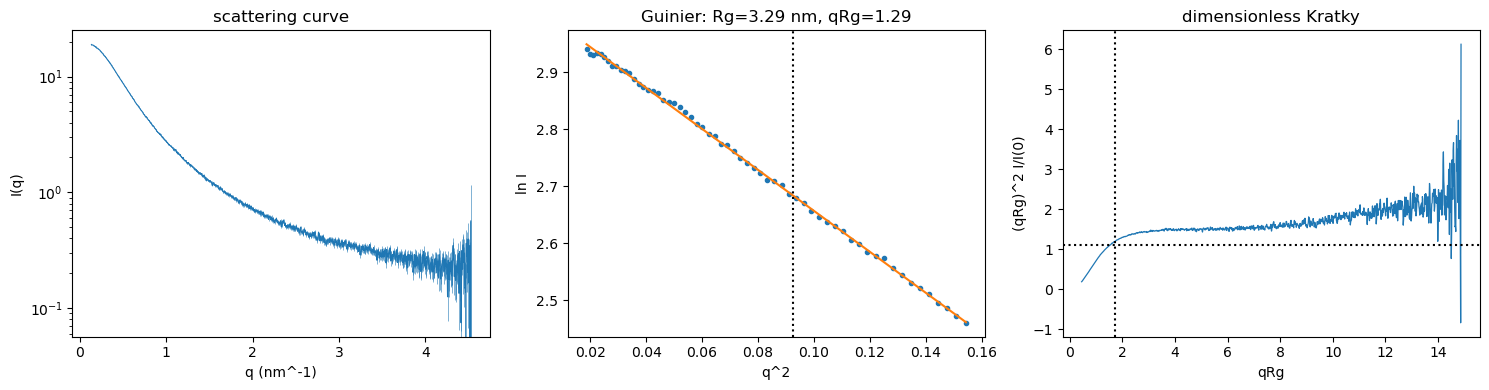

In [12]:
def guinier_fit(curve, qrg_max=1.3, n_min=10):
    """Iteratively extend the low-q window while q*Rg stays under qrg_max."""
    q, I = curve.q, curve.I
    good = (I > 0) & np.isfinite(I)
    q, I = q[good], I[good]

    best = None
    for n in range(n_min, min(len(q), 200)):
        x, y = q[:n] ** 2, np.log(I[:n])
        slope, intercept = np.polyfit(x, y, 1)
        if slope >= 0:
            continue
        Rg = np.sqrt(-3.0 * slope)
        I0 = np.exp(intercept)
        if q[n - 1] * Rg > qrg_max:
            break
        resid = y - (slope * x + intercept)
        best = {"Rg": Rg, "I0": I0, "n_points": n,
                "qmin_Rg": q[0] * Rg, "qmax_Rg": q[n - 1] * Rg,
                "resid_rms": float(np.sqrt(np.mean(resid ** 2)))}
    return best


def plot_curve(curve, guinier=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    q, I, s = curve.q, curve.I, curve.sigma

    axes[0].errorbar(q, I, yerr=s, fmt="-", lw=0.8, elinewidth=0.4)
    axes[0].set_yscale("log")
    axes[0].set_xlabel(f"q ({curve.units})"); axes[0].set_ylabel("I(q)")
    axes[0].set_title("scattering curve")

    if guinier:
        n = guinier["n_points"]
        axes[1].plot(q[:n] ** 2, np.log(I[:n]), "o", ms=3)
        sl = -guinier["Rg"] ** 2 / 3.0
        xs = q[:n] ** 2
        axes[1].plot(xs, sl * xs + np.log(guinier["I0"]), "-")
        axes[1].axvline((1.0 / guinier["Rg"]) ** 2, ls=":", c="k")
        axes[1].set_title(f"Guinier: Rg={guinier['Rg']:.2f} {curve.units.replace('^-1','')}"
                          f", qRg={guinier['qmax_Rg']:.2f}")
        axes[1].set_xlabel("q^2"); axes[1].set_ylabel("ln I")

        Rg, I0 = guinier["Rg"], guinier["I0"]
        x = q * Rg
        axes[2].plot(x, (x ** 2) * I / I0, "-", lw=0.9)
        axes[2].axvline(np.sqrt(3), ls=":", c="k")
        axes[2].axhline(1.104, ls=":", c="k")
        axes[2].set_xlabel("qRg"); axes[2].set_ylabel("(qRg)^2 I/I(0)")
        axes[2].set_title("dimensionless Kratky")

    plt.tight_layout()
    return fig


if files:
    g = guinier_fit(curve_nm)
    print(g)
    plot_curve(curve_nm, g)
    plt.show()

## 7. Batch harvesting

Pattern for pulling a benchmark set. Note the failure collection — over hundreds of entries
some will lack the file type you asked for, and you want the loop to finish and tell you.

In [13]:
def harvest(codes, exts=(".dat",), limit=None):
    results, failures = {}, {}
    for i, code in enumerate(list(codes)[:limit]):
        try:
            paths = fetch_entry_files(code, exts=exts)
            if not paths:
                failures[code] = "no matching files"
                continue
            results[code] = paths
        except Exception as e:
            failures[code] = repr(e)
        if (i + 1) % 10 == 0:
            print(f"  {i+1} done, {len(failures)} failures")
    print(f"\nharvested {len(results)}, failed {len(failures)}")
    return results, failures


# results, failures = harvest(proteins, limit=20)
# pd.Series(failures).value_counts().head()

## 8. Next steps

Open questions for you to direct:

1. **What selection?** A UniProt code, a tag, a molecular type, an instrument, or a
   concentration/Rg filter over the full summary table?
2. **Which files?** Experimental `.dat` only, or also `.fit`/`.fir` (model fits),
   `.out` (GNOM p(r)), and model coordinates?
3. **Where does this land?** If it feeds the SWAXS pipeline, the useful output is a tidy
   table of (code, q-array, I, σ, units, concentration, Rg, Dmax, instrument, buffer),
   with concentration and buffer pulled from the summary metadata — those two fields are
   what make an entry usable as a validation target rather than just a curve.
4. **Concentration series.** Entries carry a curve type (single concentration, merged,
   extrapolated to infinite dilution, SEC-SAS). For validating concentration-dependent
   aggregation you specifically want single-concentration entries with the concentration
   recorded, not merged or extrapolated ones. Worth building that filter early.